training a model for “donate within 30 days”

Inputs (X):

recency_days

frequency_365

time_months

days_until_eligible

overdue_days

Output (y):

y_donate_30d

In [ ]:
import pickle
import numpy as np
import pathlib
model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"
data_dir = model_dir / "datasets"

with open(MODEL_PATH / 
          "donor_agent_v1_updated.pkl", "rb") as f:
    data = pickle.load(f)

state = data["state"]

print("=" * 50)
print("INTERCEPT (base prediction bias):")
print("=" * 50)
print(f"  m_intercept: {state['m_intercept']}")
print(f"  v_intercept: {state['v_intercept']}")

print("\n" + "=" * 50)
print("m_int (MEAN weights — the brain):")
print("=" * 50)
m_int = state["m_int"]
for feature_name, weights in m_int.items():
    print(f"\n── {feature_name} ──")
    print(f"   Type: {type(weights)}")
    if isinstance(weights, dict):
        for category, weight in weights.items():
            print(f"     '{category}' → {weight}")
    elif hasattr(weights, "shape"):
        print(f"   Shape: {weights.shape}")
        print(f"   Values: {weights}")
    else:
        print(f"   Value: {weights}")

print("\n" + "=" * 50)
print("v_int (VARIANCE/uncertainty per feature):")
print("=" * 50)
v_int = state["v_int"]
for feature_name, var in v_int.items():
    print(f"\n── {feature_name} ──")
    if isinstance(var, dict):
        for category, v in var.items():
            print(f"     '{category}' → {v}")
    elif hasattr(var, "shape"):
        print(f"   Shape: {var.shape}, Values: {var}")
    else:
        print(f"   Value: {var}")
        
        

INTERCEPT (base prediction bias):
  m_intercept: 0.47464351890486034
  v_intercept: 0.3031133007887739

m_int (MEAN weights — the brain):

── age||recency_days ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.3573333294510975

── bmi||recency_days ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.3742881018431129

── recency_days||years_since_first_donation ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.4206035674031682

── lifetime_donation_count||recency_days ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.434209316227948

── blood_type||recency_days ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.41714284185742456

── age||bmi ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.4287189779930958

── age||years_since_first_donation ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.44424211985110496

── recency_days||sex ──
   Type: <class 'numpy.float64'>
   Shape: ()
   Values: 0.130236085417587

FULL MODEL BRAIN
Intercept: 0.4746
Total interactions: 15
                                        interaction  weight (m)  uncertainty (v)  confidence
                    age||years_since_first_donation    0.444242         0.311393    0.762548
                       age||lifetime_donation_count    0.434429         0.314045    0.761009
              lifetime_donation_count||recency_days    0.434209         0.410129    0.709155
                                           age||bmi    0.428719         0.314008    0.761030
                       bmi||lifetime_donation_count    0.428181         0.315895    0.759939
                    bmi||years_since_first_donation    0.424581         0.316776    0.759430
           recency_days||years_since_first_donation    0.420604         0.481414    0.675031
                           blood_type||recency_days    0.417143         0.308226    0.764394
                                    age||blood_type    0.413052         0.239903    0.806515
            

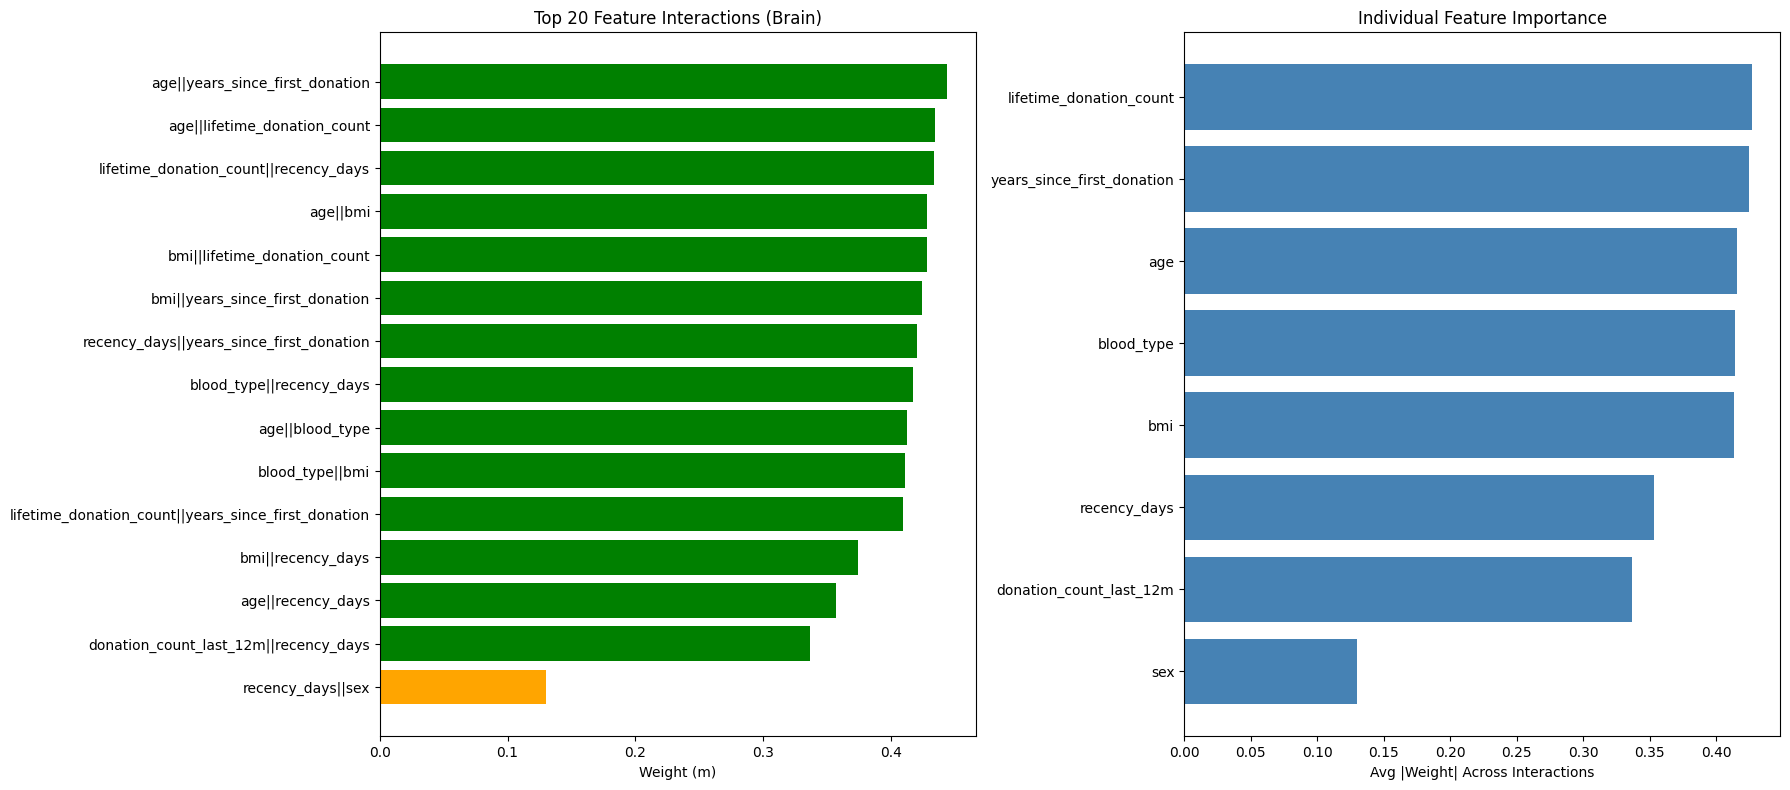


✅ Saved visualization to model_brain.png


In [ ]:
import matplotlib.pyplot as plt
state = data["state"]
m_int = state["m_int"]
v_int = state["v_int"]


rows = []
for feature_name, weight in m_int.items():
    w = float(weight)
    v = float(v_int.get(feature_name, 0))
    rows.append({
        "interaction": feature_name,
        "weight (m)": w,
        "uncertainty (v)": v,
        "confidence": 1 / (1 + v),
    })

brain_df = pd.DataFrame(rows).sort_values("weight (m)", ascending=False)
brain_df.reset_index(drop=True, inplace=True)

print("=" * 60)
print("FULL MODEL BRAIN")
print(f"Intercept: {state['m_intercept']:.4f}")
print(f"Total interactions: {len(brain_df)}")
print("=" * 60)
print(brain_df.to_string(index=False))


feature_scores = {}
for _, row in brain_df.iterrows():
    parts = row["interaction"].split("||")
    for feat in parts:
        feat = feat.strip()
        if feat not in feature_scores:
            feature_scores[feat] = []
        feature_scores[feat].append(abs(row["weight (m)"]))

importance_df = pd.DataFrame([
    {"feature": feat, "avg_abs_weight": np.mean(scores), "num_interactions": len(scores)}
    for feat, scores in feature_scores.items()
]).sort_values("avg_abs_weight", ascending=False)

print("\n" + "=" * 60)
print("INDIVIDUAL FEATURE IMPORTANCE (aggregated)")
print("=" * 60)
print(importance_df.to_string(index=False))

# ── 3. Visualize ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Top interactions by weight
top = brain_df.head(20)
colors = ["green" if w > 0.3 else "orange" if w > 0.1 else "red" for w in top["weight (m)"]]
axes[0].barh(top["interaction"], top["weight (m)"], color=colors)
axes[0].set_xlabel("Weight (m)")
axes[0].set_title("Top 20 Feature Interactions (Brain)")
axes[0].invert_yaxis()

# Right: Individual feature importance
axes[1].barh(importance_df["feature"], importance_df["avg_abs_weight"], color="steelblue")
axes[1].set_xlabel("Avg |Weight| Across Interactions")
axes[1].set_title("Individual Feature Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("model_brain.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Saved visualization to model_brain.png")

In [1]:
import pathlib
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
    
model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"
data_dir = model_dir / "datasets"
df = pd.read_csv(data_dir / "donor_snapshots_with_targets.csv")

feature_cols = ["recency_days","frequency_365","time_months","days_until_eligible","overdue_days"]
target_col = "y_donate_30d"

X = df[feature_cols]
y = df[target_col]

# split by donor_id so the same donor doesn't appear in train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["donor_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, proba))
print("PR AUC :", average_precision_score(y_test, proba))



ROC AUC: 0.8322858858929814
PR AUC : 0.6825891735769534


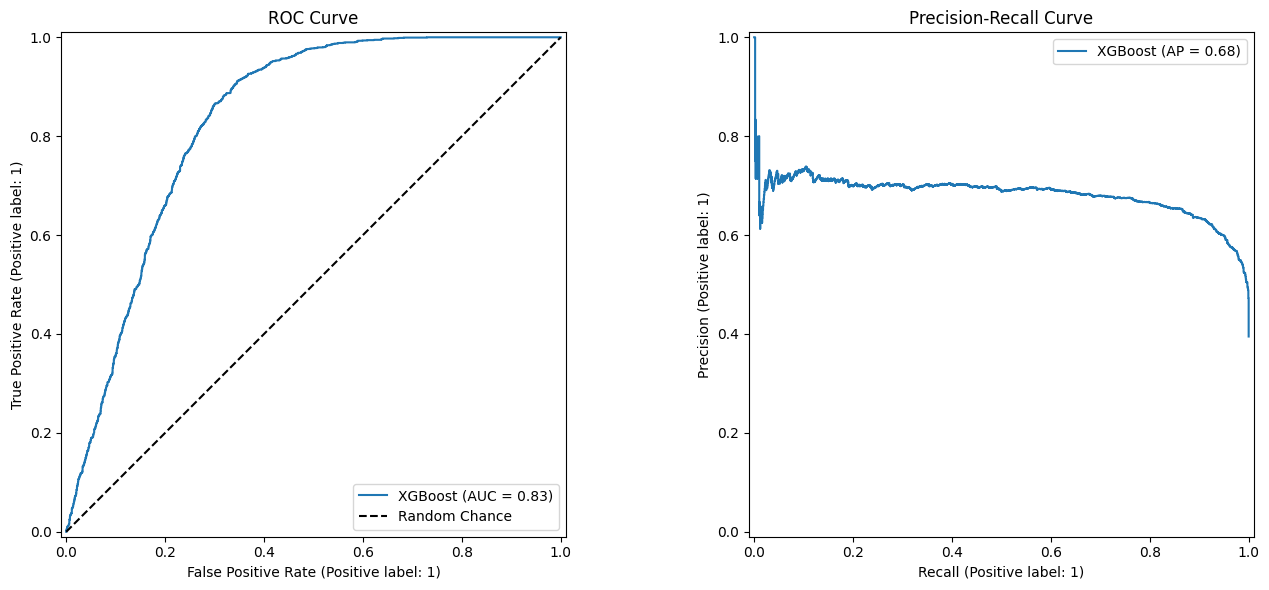

<Figure size 1000x600 with 0 Axes>

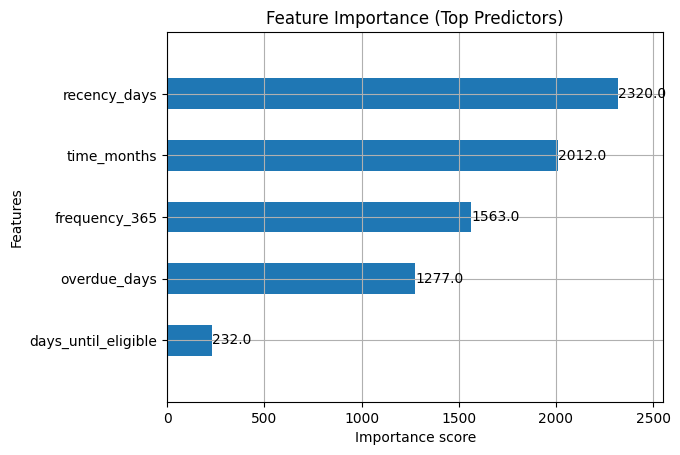

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from xgboost import plot_importance


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


# Note: This uses the model and test data directly
RocCurveDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    name="XGBoost",
    ax=ax1
)
ax1.set_title("ROC Curve")
ax1.plot([0, 1], [0, 1], "k--", label="Random Chance")
ax1.legend()

# 2. Plot Precision-Recall Curve (Crucial for Imbalanced Donor Data)
PrecisionRecallDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    name="XGBoost",
    ax=ax2
)
ax2.set_title("Precision-Recall Curve")
ax2.legend()

plt.tight_layout()
plt.show()

# 3. Plot Feature Importance (To understand WHAT drives donations)
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='weight', max_num_features=10, height=0.5)
plt.title("Feature Importance (Top Predictors)")
plt.show()

In [4]:
#If you run a report for your marketing team, you will likely filter out ineligible people anyway. You need to know if the model can differentiate between Eligible Person A (who won't donate) and Eligible Person B (who will).
# Create a mask for people who are actually allowed to donate right now
# (Assuming 'days_until_eligible' <= 0 means they can donate)
eligible_mask = X_test['days_until_eligible'] <= 0

# Filter the test set
X_test_eligible = X_test[eligible_mask]
y_test_eligible = y_test[eligible_mask]

# Get probabilities for this subset
proba_eligible = model.predict_proba(X_test_eligible)[:, 1]

print("--- Performance on ELIGIBLE Donors Only ---")
print("ROC AUC:", roc_auc_score(y_test_eligible, proba_eligible))
print("PR AUC :", average_precision_score(y_test_eligible, proba_eligible))

--- Performance on ELIGIBLE Donors Only ---
ROC AUC: 0.7678423304515325
PR AUC : 0.7000693723299426


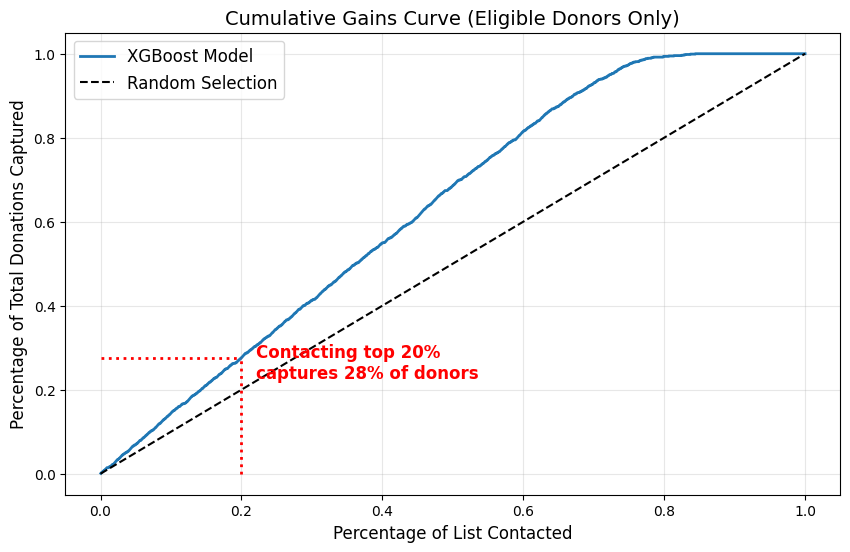

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Create a DataFrame with actuals and predicted probabilities
results = pd.DataFrame({
    'actual': y_test_eligible,
    'proba': proba_eligible
})

# Sort by probability (highest first)
results = results.sort_values(by='proba', ascending=False)

# Calculate cumulative metrics
results['cumulative_donors'] = results['actual'].cumsum()
results['cumulative_total'] = np.arange(1, len(results) + 1)

# Calculate percentages
results['percent_population'] = results['cumulative_total'] / len(results)
results['percent_captured_donors'] = results['cumulative_donors'] / results['actual'].sum()

# Plot
plt.figure(figsize=(10, 6))

# Plot the Model Curve
plt.plot(results['percent_population'], results['percent_captured_donors'], label='XGBoost Model', linewidth=2)

# Plot the "Random Guess" Baseline (diagonal)
plt.plot([0, 1], [0, 1], 'k--', label='Random Selection')

# Formatting
plt.title('Cumulative Gains Curve (Eligible Donors Only)', fontsize=14)
plt.xlabel('Percentage of List Contacted', fontsize=12)
plt.ylabel('Percentage of Total Donations Captured', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add annotations for the "Sweet Spot"
# Find the value at 20% population
capture_at_20 = results[results['percent_population'] >= 0.20]['percent_captured_donors'].iloc[0]

plt.plot([0.2, 0.2], [0, capture_at_20], 'r:', linewidth=2)
plt.plot([0, 0.2], [capture_at_20, capture_at_20], 'r:', linewidth=2)
plt.text(0.22, capture_at_20 - 0.05, f'Contacting top 20% \ncaptures {capture_at_20:.0%} of donors', color='red', fontsize=12, fontweight='bold')

plt.show()

In [9]:
print(feature_cols)

['recency_days', 'frequency_365', 'time_months', 'days_until_eligible', 'overdue_days']


In [10]:
""" import joblib

out_path = "donation_model_30d.pkl"
joblib.dump(model, out_path)
print("Saved:", out_path) """
from UniversalModelExporter import UniversalModelExporter

my_features = feature_cols 

# 2. Export the model
UniversalModelExporter.export_xgboost(
    model=model,
    output_path="donation_30d_clf.pkl",
    description="classifier to predict if a donor will donate in the next 30 days",
    feature_names=my_features
)

📦 [XGBoost] Saved to donation_30d_clf.pkl


In [11]:
import joblib
clf = joblib.load(MODEL_PATH / "donation_30d_clf.pkl")
x_one = pd.DataFrame([{
    "recency_days": 70,
    "frequency_365": 5,
    "time_months": 48.0,
    "days_until_eligible": 0,
    "overdue_days": 14
}])

p30 = clf.predict_proba(x_one)[0, 1]
print("Probability donate in 30d:", p30)

Probability donate in 30d: 0.9419009


In [12]:
df30 = df[df["days_until_eligible"] <= 30].copy()

df30["y_donate_30d"].mean()


0.47328971606428255

In [13]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.5, 0.7, 0.8]

for th in thresholds:
    pred = (proba >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    print(th, "precision=", round(p,3), "recall=", round(r,3))


0.3 precision= 0.62 recall= 0.926
0.5 precision= 0.664 recall= 0.81
0.7 precision= 0.701 recall= 0.302
0.8 precision= 0.716 recall= 0.047


In [17]:
# trying to predict how many days until next donation (regression)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# 1. Load Data
data_dir = model_dir / "datasets"
df = pd.read_csv(data_dir / "donor_snapshots_with_targets.csv")

# 2. Define Features and Targets
feature_cols = ["recency_days","frequency_365","time_months","days_until_eligible","overdue_days"]

# IMPORTANT: This target column must contain actual days (e.g., 5, 20, 45). 
# It should be NaN (or filtered out) for people who didn't donate.
target_days_col = "days_to_next_donation" 

# Filter: We only TRAIN the regression model on people who actually came back.
# If we train on the non-donors (NaN), the model will break.
df_reg = df[df[target_days_col].notna()].copy()

X = df_reg[feature_cols]
y = df_reg[target_days_col]
groups = df_reg["donor_id"]

# 3. Split (Grouped by ID, just like before)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Define the Regressor
reg_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,            # Slightly shallower depth often works better for regression
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror', # Optimized to minimize "Days Off" (MAE)
    n_jobs=-1,
    random_state=42
)

# 5. Fit the model
reg_model.fit(X_train, y_train)

# 6. Evaluate
preds = reg_model.predict(X_test)

# Force predictions to be positive (can't donate in -5 days)
preds = np.maximum(preds, 1) 

print(f"Mean Absolute Error: {mean_absolute_error(y_test, preds):.2f} days")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")


Mean Absolute Error: 10.65 days
R2 Score: 0.9483


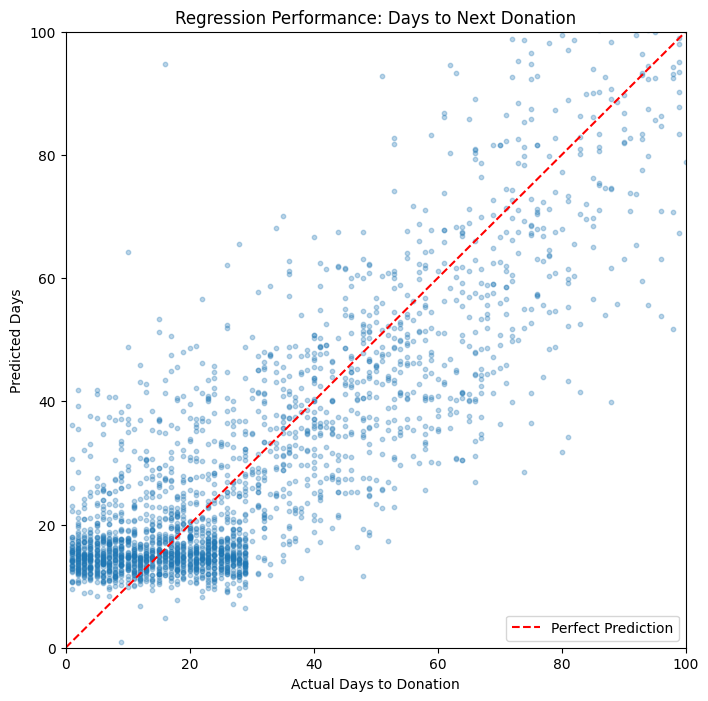

In [18]:

# 7. Visualization: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.3, s=10)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect Prediction') # Diagonal line
plt.xlabel("Actual Days to Donation")
plt.ylabel("Predicted Days")
plt.title("Regression Performance: Days to Next Donation")
plt.xlim(0, 100) # Zoom in on the next 3 months
plt.ylim(0, 100)
plt.legend()
plt.show()

In [19]:
# Quick check to see the correlation
# Recency should correlate with Days to Next (but inversely or cyclically)
print(df[['recency_days', 'days_to_next_donation']].corr())

                       recency_days  days_to_next_donation
recency_days               1.000000              -0.110143
days_to_next_donation     -0.110143               1.000000


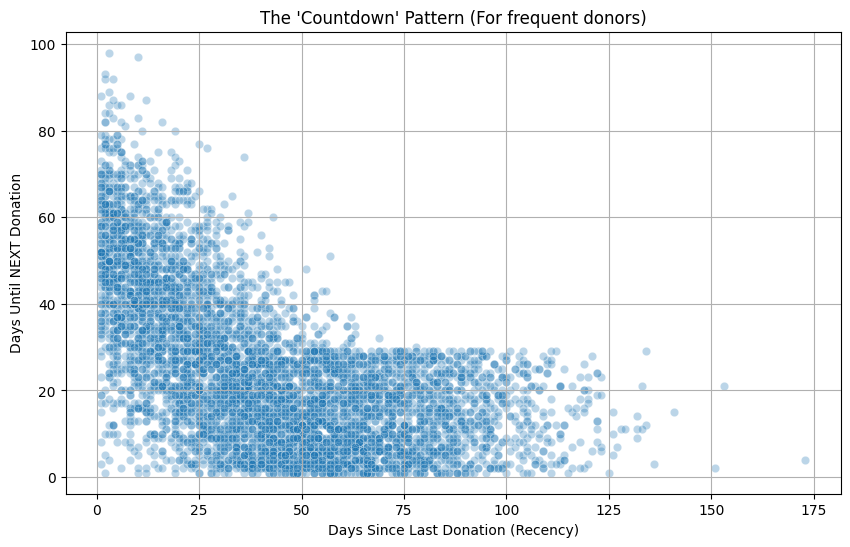

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to just one specific group (e.g., people who donate ~every 2 months)
# This removes the noise from the yearly donors so you can see the pattern clearly
subset = df[ (df['frequency_365'] >= 5) & (df['frequency_365'] <= 7) ]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='recency_days', y='days_to_next_donation', alpha=0.3)
plt.title("The 'Countdown' Pattern (For frequent donors)")
plt.xlabel("Days Since Last Donation (Recency)")
plt.ylabel("Days Until NEXT Donation")
plt.grid(True)
plt.show()

In [21]:
from UniversalModelExporter import UniversalModelExporter

my_features = [
    "recency_days", 
    "frequency_365", 
    "time_months", 
    "days_until_eligible", 
    "overdue_days"
]

UniversalModelExporter.export_xgboost(
    model=reg_model,
    output_path="days_to_next_donation_reg.pkl",
    description="how many days until next donation for each donor",
    feature_names=my_features
)

📦 [XGBoost] Saved to days_to_next_donation_reg.pkl
